In [1]:
%cd /home/maia-user/NeuroCBIR/

/home/maia-user/NeuroCBIR


In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

### Input data
# Path to dataset
DATA_PATH = "/home/maia-user/cifs/Datasets/"

In [3]:
# Load metadata
import pandas as pd
import os

# Your existing list of DataFrames
clinical_ds = [
    pd.read_csv(os.path.join(DATA_PATH, "ADNI", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "OASIS3", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "AIBL", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "SLIM", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "MIRIAD", "metadata.csv"))
]

# Combine into a single DataFrame
clinical_ds = pd.concat(clinical_ds, axis=0, ignore_index=True)

# (Optional) check shape and columns
print(clinical_ds.shape)
print(clinical_ds.columns)

(26693, 15)
Index(['GUID', 'project', 'subject', 'timepoint', 'scan_type',
       'field_strength', 'manufacturer', 'model_name', 'disease', 'age',
       'brain', 'sex', 'acq_date', 'raw', 'seg'],
      dtype='object')


In [4]:
clinical_ds.manufacturer.unique()

array([nan, 'GE MEDICAL SYSTEMS', 'Philips Medical Systems', 'SIEMENS',
       'Philips Healthcare', 'Siemens'], dtype=object)

In [5]:
disease_mapping = {
    "CN": "CN", "Normal": "CN", "Control": "CN",
    "MCI": "MCI", "Mild Cognitive Impairment": "MCI", "EMCI": "MCI", "LMCI": "MCI", "SMC": "MCI",
    "AD": "AD", "Alzheimer's Disease": "AD"
}

manufacturer_mapping = {
    "Siemens": "SH", "Siemens Healthineers": "SH", "SIEMENS": "SH",
    "GE": "GE", "GE MEDICAL SYSTEMS": "GE"
}


import pandas as pd

# Map disease categories
clinical_ds['disease_cat'] = clinical_ds['disease'].map(disease_mapping).fillna("Other")

# Map manufacturers
clinical_ds['manufacturer_cat'] = clinical_ds['manufacturer'].map(manufacturer_mapping).fillna("Other")

# Function to compute summary per project
def summarize_project(df):
    return pd.Series({
        "NI": len(df),  # total scans
        "NS": df['subject'].nunique(),  # unique subjects
        "Age": f"{df['age'].mean():.1f} ± {df['age'].std():.1f}",  # mean ± std
        "CN": (df['disease_cat'] == "CN").sum(),
        "MCI": (df['disease_cat'] == "MCI").sum(),
        "AD": (df['disease_cat'] == "AD").sum(),
        "Other": (df['disease_cat'] == "Other").sum(),
        "1.5T": (df['field_strength'] == 1.5).sum(),
        "3T": (df['field_strength'] == 3).sum(),
        "SH": (df['manufacturer_cat'] == "SH").sum(),
        "GE": (df['manufacturer_cat'] == "GE").sum(),
        "Other_manufacturer": (df['manufacturer_cat'] == "Other").sum()
    })

# Group and summarize
summary_table = clinical_ds.groupby("project").apply(summarize_project).reset_index()

# Rename columns for display
summary_table.columns = [
    "Dataset", "NI", "NS", "Age", "CN", "MCI", "AD", "Other", "1.5T", "3T", "SH", "GE", "Other"
]

print(summary_table)



  Dataset     NI    NS         Age    CN    MCI    AD  Other  1.5T    3T  \
0    adni  20971  2422  73.6 ± 7.1  6360  11926  2670     15  8114  9101   
1    aibl   1296   691  73.6 ± 6.7   947    184   158      7   269  1027   
2  miriad    708    69  69.7 ± 6.9   243      0   465      0   708     0   
3  oasis3   2681  1316  70.5 ± 9.1  2183    395   102      1   212  2464   
4    slim   1037   588  20.7 ± 1.4  1037      0     0      0     0  1037   

     SH    GE  Other  
0  7587  3662   9722  
1  1296     0      0  
2     0   708      0  
3  2681     0      0  
4  1037     0      0  


/tmp/ipykernel_228900/3644031043.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_table = clinical_ds.groupby("project").apply(summarize_project).reset_index()


In [ ]:
import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np



In [14]:
from monai.networks.nets import resnet10
from utils import load_config_from_path
import os
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = resnet10(n_input_channels=1, 
                     feed_forward=False,
                     shortcut_type="B",
                     bias_downsample=False,                
                     pretrained = True, 
                     progress = True)

# Wrapper model with resampling at the beginning
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResampleWrapper(nn.Module):
    def __init__(self, model, target_shape=(73, 96, 96)):
        super().__init__()
        self.model = model
        self.target_shape = target_shape

    def forward(self, x):
        # Ensure input is float and shape [B, 1, D, H, W]
        x = x.float()
        x = F.interpolate(
            x, size=self.target_shape, mode="trilinear", align_corners=False
        )
        return self.model(x)

img_size = [64, 128, 128]
model = ResampleWrapper(encoder, target_shape=img_size)
model = model.to(device)



In [31]:
from tqdm import tqdm
import numpy as np
import torch
from scipy.linalg import sqrtm


def crop_mri(image, target_shape=(160, 176, 208), start=[48, 38, 10]):
    end = np.minimum(np.array(start) + np.array(target_shape), image.shape)
    cropped = image[start[0]:end[0], start[1]:end[1], start[2]:end[2]]
    return cropped

def load_nifti(path, data_path, target_shape=(160, 176, 208), start=[48, 38, 10]):
    """Load a nii.gz or mgz file given a relative path from metadata."""
    full_path = os.path.join(data_path, path)
    img = nib.load(full_path)
    return crop_mri(img.get_fdata(), target_shape=target_shape, start=start)

def load_and_preprocess(paths, data_path, target_shape=(160, 176, 208), start=[48, 38, 10]):
    num_images = len(paths)
    images = np.zeros((num_images, *target_shape), dtype=np.uint8)  # Preallocate uint8

    for idx, p in enumerate(tqdm(paths, desc="Loading and cropping images")):
        img = load_nifti(p, data_path, target_shape=target_shape, start=start)  # Your existing function returns cropped image
        # Normalize to 0–255 and convert to uint8
        img_norm = 255 * (img - np.min(img)) / (np.ptp(img) + 1e-8)
        images[idx] = img_norm.astype(np.uint8)

    return images

def extract_features(images, model, device="cuda"):
    batch_size = 1
    model.eval()
    features = []

    for i in tqdm(range(0, len(images), batch_size), desc="Extracting features"):
        batch = images[i:i+batch_size].astype(np.float32) / 255.0
        batch = torch.tensor(batch).unsqueeze(1).to(device)  # [B, 1, D, H, W]
        with torch.no_grad():
            feats = model(batch)
        features.append(feats.cpu().numpy())

    return np.concatenate(features, axis=0)

def calculate_faed(feats1, feats2):
    mu1, sigma1 = np.mean(feats1, axis=0), np.cov(feats1, rowvar=False)
    mu2, sigma2 = np.mean(feats2, axis=0), np.cov(feats2, rowvar=False)
    diff = mu1 - mu2
    covmean = sqrtm(sigma1 @ sigma2)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)


In [43]:
from tqdm import tqdm

# Sample paths
sampled_paths = {}
for dataset, group in tqdm(clinical_ds.groupby("project"), desc="Sampling datasets"):
    sampled_paths[dataset] = group.sample(n=25, random_state=42)["brain"].tolist()

# Preload all images (preallocate uint8 arrays)
preloaded_images = {}
for dataset in sampled_paths.keys():
    print(f"Preloading {dataset}...")
    preloaded_images[dataset] = load_and_preprocess(sampled_paths[dataset], DATA_PATH, target_shape=(50, 60, 102), start=[100, 80, 52])
    


Sampling datasets: 100%|██████████| 5/5 [00:00<00:00, 173.75it/s]


Preloading adni...


Loading and cropping images:   0%|          | 0/25 [00:00<?, ?it/s]

Loading and cropping images: 100%|██████████| 25/25 [00:07<00:00,  3.42it/s]


Preloading aibl...


...

Loading and cropping images: 100%|██████████| 25/25 [00:07<00:00,  3.47it/s]


Preloading oasis3...


Loading and cropping images: 100%|██████████| 25/25 [00:08<00:00,  3.02it/s]


Preloading slim...


Loading and cropping images: 100%|██████████| 25/25 [00:07<00:00,  3.14it/s]


Image shape: (50, 60, 102)


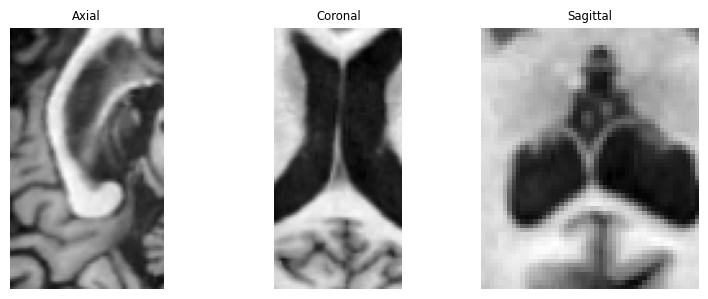

In [44]:
import matplotlib.pyplot as plt

# Load one MRI image
img = load_nifti(sampled_paths["adni"][0], DATA_PATH, target_shape=(50, 60, 102), start=[100, 80, 52])  # example: first ADNI scan
print("Image shape:", img.shape)  # should be (D, H, W) = (z, y, x)

# Pick middle slices
z_mid = img.shape[0] // 2  # axial
y_mid = img.shape[1] // 2  # coronal
x_mid = img.shape[2] // 2  # sagittal

# Plot
fig, axes = plt.subplots(1, 3, figsize=(8, 3))

# Axial (slice along z-axis)
axes[0].imshow(img[z_mid, :, :].T, cmap="gray", origin="lower")
axes[0].set_title("Axial")

# Coronal (slice along y-axis)
axes[1].imshow(img[:, y_mid, :].T, cmap="gray", origin="lower")
axes[1].set_title("Coronal")

# Sagittal (slice along x-axis)
axes[2].imshow(img[:, :, x_mid].T, cmap="gray", origin="lower")
axes[2].set_title("Sagittal")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [45]:
features_cache = {}
for dataset in preloaded_images.keys():
    print(f"Extract features {dataset}...")
    features_cache[dataset] = extract_features(preloaded_images[dataset], model, device=device)

Extract features adni...


Extracting features: 100%|██████████| 25/25 [00:00<00:00, 106.80it/s]


Extract features aibl...


Extracting features: 100%|██████████| 25/25 [00:00<00:00, 85.85it/s]


Extract features miriad...


Extracting features: 100%|██████████| 25/25 [00:00<00:00, 79.74it/s]


Extract features oasis3...


Extracting features: 100%|██████████| 25/25 [00:00<00:00, 88.46it/s] 


Extract features slim...


Extracting features: 100%|██████████| 25/25 [00:00<00:00, 83.33it/s]


In [46]:
datasets = list(sampled_paths.keys())
faed_matrix = np.zeros((len(datasets), len(datasets)))

print("Computing FAED matrix")
for i, d1 in enumerate(datasets):
    feats1 = features_cache[d1]

    for j, d2 in enumerate(datasets):
        print(f"Comparing {d1} and {d2}")
        feats2 = features_cache[d2]
        faed_matrix[i, j] = calculate_faed(feats1, feats2)


Computing FAED matrix
Comparing adni and adni


/tmp/ipykernel_228900/3262371264.py:48: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = sqrtm(sigma1 @ sigma2)


Comparing adni and aibl
Comparing adni and miriad
Comparing adni and oasis3
Comparing adni and slim
Comparing aibl and adni
Comparing aibl and aibl
Comparing aibl and miriad
Comparing aibl and oasis3
Comparing aibl and slim
Comparing miriad and adni
Comparing miriad and aibl
Comparing miriad and miriad
Comparing miriad and oasis3
Comparing miriad and slim
Comparing oasis3 and adni
Comparing oasis3 and aibl
Comparing oasis3 and miriad
Comparing oasis3 and oasis3
Comparing oasis3 and slim
Comparing slim and adni
Comparing slim and aibl
Comparing slim and miriad
Comparing slim and oasis3
Comparing slim and slim


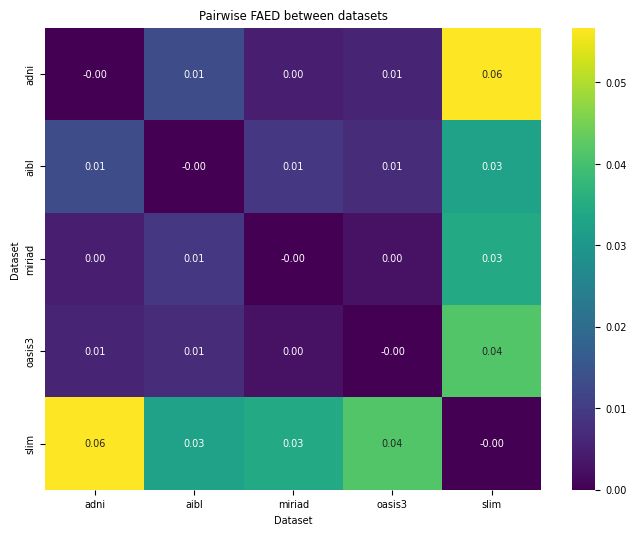

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('default')
plt.rcParams.update({'font.size': 7})

plt.figure(figsize=(8, 6))
sns.heatmap(faed_matrix, annot=True, fmt=".2f", xticklabels=datasets, yticklabels=datasets, cmap="viridis")
plt.title("Pairwise FAED between datasets")
plt.xlabel("Dataset")
plt.ylabel("Dataset")
plt.show()
